# OtoMetrik — EDA & Preprocessing

Faz 8: `data/output/train_dataset.csv` (train), `data/output/cars1_normalized.csv` (validation),
`data/output/arabam_test_val_normalized.csv` (canlı test, şu an 20 kayıt) kaynaklarının keşifsel analizi.

## Madde 1 — Temel istatistikler & eksik değer haritası

Her kaynağın boyutu, kolon tipleri, sayısal alan özetleri ve eksik değer oranları.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_DIR = os.path.join('..', '..', 'data', 'output')

SOURCES = {
    'train_dataset': pd.read_csv(os.path.join(DATA_DIR, 'train_dataset.csv'), low_memory=False),
    'cars1_validation': pd.read_csv(os.path.join(DATA_DIR, 'cars1_normalized.csv'), low_memory=False),
    'arabam_test': pd.read_csv(os.path.join(DATA_DIR, 'arabam_test_val_normalized.csv'), low_memory=False),
}

for name, df in SOURCES.items():
    print(f'{name}: {df.shape[0]} satir, {df.shape[1]} kolon')

train_dataset: 53205 satir, 17 kolon
cars1_validation: 53514 satir, 18 kolon
arabam_test: 20 satir, 17 kolon


In [2]:
for name, df in SOURCES.items():
    print(f'=== {name}: dtype + eksik deger % ===')
    summary = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'eksik_%': (df.isna().mean() * 100).round(1),
    })
    display(summary)

=== train_dataset: dtype + eksik deger % ===


,dtype,eksik_%
ilan_id,str,0.0
arac_turu,float64,100.0
marka,str,0.3
model,str,0.3
paket,str,0.6
kasa_turu,str,0.5
renk,str,0.3
motor_hacmi,float64,3.2
motor_gucu,float64,3.2
yil,float64,0.3


=== cars1_validation: dtype + eksik deger % ===


,dtype,eksik_%
konum,str,0.0
fiyat,float64,0.0
marka,str,0.0
seri,str,0.0
model,str,0.0
yil,int64,0.0
kilometre,float64,0.0
vites_tipi,str,0.0
yakit_tipi,str,0.0
kasa_tipi,str,0.1


=== arabam_test: dtype + eksik deger % ===


,dtype,eksik_%
ilan_id,int64,0.0
arac_turu,str,0.0
marka,str,0.0
model,str,0.0
paket,str,5.0
kasa_turu,str,0.0
renk,str,0.0
motor_hacmi,float64,0.0
motor_gucu,float64,0.0
yil,int64,0.0


In [3]:
for name, df in SOURCES.items():
    print(f'=== {name}: sayisal alan ozeti ===')
    display(df.describe())

=== train_dataset: sayisal alan ozeti ===


,arac_turu,motor_hacmi,motor_gucu,yil,kilometre,degisen_sayisi,boyali_sayisi,fiyat
count,0.0,5.151600e+04,51487.000000,53047.000000,5.304700e+04,42296.000000,42296.000000,5.304700e+04
mean,NaN,1.541539e+06,1531.594325,2010.437178,2.006868e+05,0.560620,2.422853,9.653328e+05
std,NaN,1.526861e+07,13919.228852,8.517997,7.414977e+05,0.937314,3.072702,6.495963e+06
min,NaN,6.580000e+02,39.000000,1951.000000,0.000000e+00,0.000000,0.000000,1.000000e+04
25%,NaN,1.372000e+03,88.000000,2005.000000,1.150000e+05,0.000000,0.000000,3.650000e+05
50%,NaN,1.500000e+03,107.000000,2012.000000,1.880000e+05,0.000000,1.000000,6.150000e+05
75%,NaN,1.597000e+03,125.000000,2017.000000,2.550000e+05,1.000000,4.000000,1.029950e+06
max,NaN,4.501500e+08,551575.000000,2025.000000,9.000000e+07,10.000000,12.000000,5.950000e+08


=== cars1_validation: sayisal alan ozeti ===


,fiyat,yil,kilometre,motor_hacmi,motor_gucu,ortalama_yakit_tuketimi,yakit_deposu,tramer,degisen,boyali
count,5.351400e+04,53514.000000,5.351400e+04,53496.000000,53428.000000,53514.000000,53514.000000,5.351400e+04,53514.000000,53514.000000
mean,7.632365e+05,2011.184849,2.026344e+05,1455.893487,103.542150,5.678094,52.364465,3.434185e+04,0.450779,1.906436
std,4.714006e+05,7.191565,2.846441e+05,234.298465,28.804749,1.356454,7.921370,8.285871e+05,0.849997,2.862187
min,1.000000e+04,1977.000000,6.000000e+03,796.000000,41.000000,0.400000,30.000000,0.000000e+00,0.000000,0.000000
25%,4.100000e+05,2006.000000,1.300000e+05,1339.000000,83.000000,4.500000,45.000000,0.000000e+00,0.000000,0.000000
50%,6.450000e+05,2012.000000,1.975000e+05,1401.000000,101.000000,5.600000,50.000000,0.000000e+00,0.000000,0.000000
75%,9.950000e+05,2016.000000,2.609950e+05,1596.000000,115.000000,6.700000,56.000000,0.000000e+00,1.000000,3.000000
max,3.249750e+06,2026.000000,2.700000e+07,6001.000000,601.000000,13.900000,100.000000,3.112202e+07,11.000000,12.000000


=== arabam_test: sayisal alan ozeti ===


,ilan_id,motor_hacmi,motor_gucu,yil,kilometre,degisen_sayisi,boyali_sayisi,fiyat
count,2.000000e+01,20.00000,20.000000,20.000000,20.000000,19.000000,19.000000,2.000000e+01
mean,4.115401e+07,1451.95000,111.100000,2013.850000,199165.000000,0.526316,3.789474,9.266500e+05
std,1.442492e+06,367.07363,42.213617,9.183939,133141.662881,0.611775,3.326308,5.887716e+05
min,3.531295e+07,600.00000,25.000000,1991.000000,14000.000000,0.000000,0.000000,1.670000e+05
25%,4.142983e+07,1407.75000,89.500000,2011.000000,68750.000000,0.000000,1.000000,5.925000e+05
50%,4.146771e+07,1560.00000,110.000000,2014.000000,216000.000000,0.000000,3.000000,7.175000e+05
75%,4.184601e+07,1598.00000,136.500000,2020.000000,271250.000000,1.000000,6.500000,1.107500e+06
max,4.185105e+07,1900.50000,213.000000,2025.000000,433000.000000,2.000000,11.000000,2.650000e+06


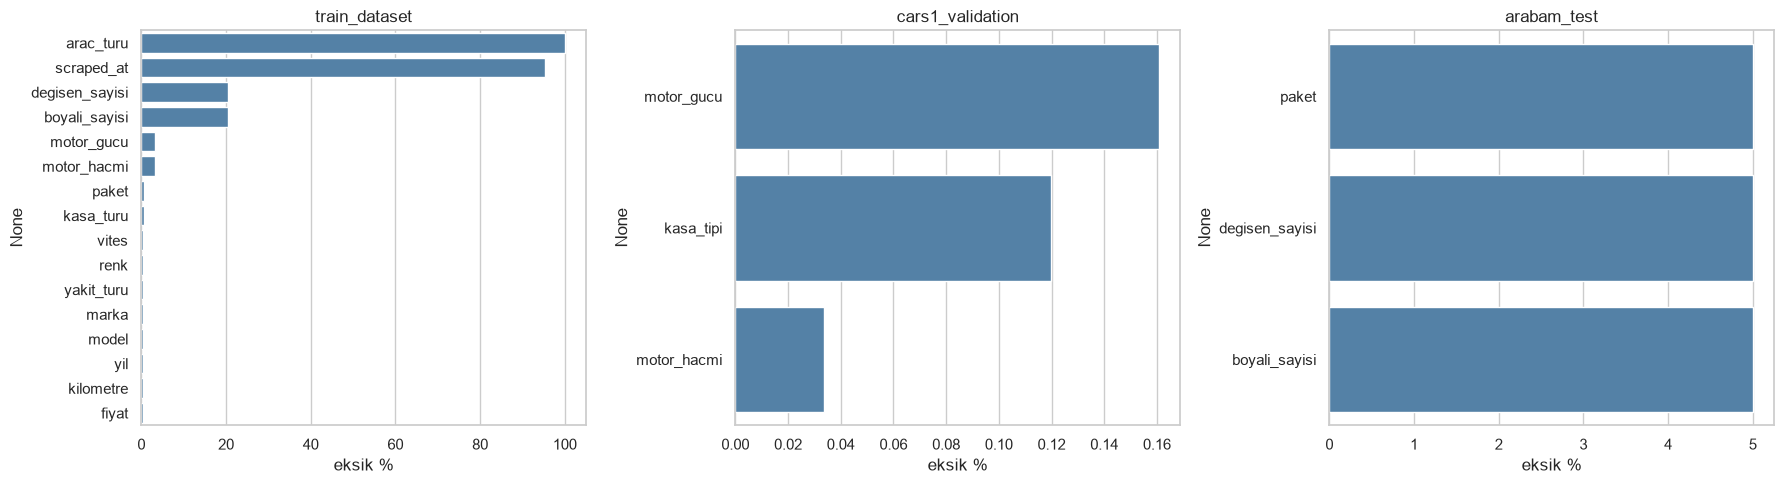

In [4]:
fig, axes = plt.subplots(1, len(SOURCES), figsize=(18, 5), sharey=False)
for ax, (name, df) in zip(axes, SOURCES.items()):
    missing = (df.isna().mean() * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    sns.barplot(x=missing.values, y=missing.index, ax=ax, color='steelblue')
    ax.set_title(name)
    ax.set_xlabel('eksik %')
plt.tight_layout()
plt.show()